<a href="https://colab.research.google.com/github/blumkina/blumkina/blob/main/notebooks/homework/hw-02-erm-least-squares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашняя работа 2. Такси Нью-Йорка: восстанавливаем тариф

**Курс «Машинное обучение», 4 курс**

| | |
|---|---|
| К лабораторной | занятие 2 — Эмпирический риск и метод наименьших квадратов |
| Опора | материал занятия 2 и лекции 1 |
| Ожидаемое время | около 2 часов |
| Данные | поездки жёлтого такси Нью-Йорка, **ваш месяц** (по фамилии) |

Комиссия по такси и лимузинам Нью-Йорка публикует каждую поездку жёлтого такси. Тариф известен и записан на сайте комиссии: посадка, цена за расстояние и цена за время в пробке. Мы сделаем вид, что его не знаем, и восстановим по данным — а потом сверим с официальным.

Три задачи: свои функции МНК, тариф обычной поездки и поездки в аэропорт по фиксированной цене. Почти везде каркас уже написан, дописать нужно одну-две строки.

> **Чем это отличается от занятия.** На занятии данные были учебные и общие — так удобно разбирать у доски. Дома у каждого свой месяц поездок: он вычисляется по фамилии, и у соседа месяц другой. Мало того, в декабре 2022 года тариф повышали, так что у половины группы он старый, а у половины новый. Приёмы те же, числа свои.

## Что нужно сдать

Заполненный ноутбук, в котором:

1. выполнены все ячейки с `# TODO`, код исполняется сверху вниз без ошибок в свежем ядре (Kernel → Restart & Run All), а ячейки «Проверка» проходят;
2. под каждым заданием заполнена ячейка **Вывод** — своими словами, со ссылкой на полученные числа;
3. графики подписаны: заголовок, оси, легенда;
4. в ячейке варианта вписана ваша фамилия.

МНК считается только вашей функцией `ols_fit`; `scikit-learn` — лишь для сверки, а `np.polyfit` и `np.linalg.lstsq` использовать нельзя.

На сдаче — устная защита: объяснить свой код и прямо при преподавателе поменять в нём что-нибудь. Без защиты работа не засчитывается.

> Списывание видно сразу: у каждого свой месяц поездок и своя подвыборка, поэтому и числа свои.

In [56]:
# Служебная ячейка: импорты, стиль графиков, модули и данные курса.
import sys, pathlib, urllib.request, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (6, 4)

# Файлы практикума ищем рядом с ноутбуком; если их нет -- значит, ноутбук
# открыт в Colab, и мы скачиваем их из репозитория курса.
COURSE_FILES_URL = "https://raw.githubusercontent.com/sharipovaka/ml_labs/main/notebooks"


def course_file(name, folder=""):
    """Путь к файлу курса: ищем рядом, иначе скачиваем."""
    for parent in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents][:4]:
        for candidate in (parent / name, parent / "data" / name):
            if candidate.exists():
                return candidate
    urllib.request.urlretrieve(f"{COURSE_FILES_URL}/{folder}{name}", name)
    print(f"загружен {name} из репозитория курса")
    return pathlib.Path(name)


sys.path.insert(0, str(course_file("variants.py").parent))
from variants import student_seed, submission_name  # noqa: E402

## Индивидуальный вариант

Впишите свою фамилию в переменную `STUDENT` — вариант вычисляется по ней и при повторном запуске остаётся тем же.

Регистр, лишние пробелы и написание «ё»/«е» роли не играют. А вот лишние слова — играют: пишите только фамилию, иначе вариант будет другим. Если в группе есть однофамильцы, преподаватель попросит добавить инициал (например, `Петрова А.`) — тогда так же должно быть записано и в списке группы.

In [57]:
STUDENT = "Blumkina"   # <-- впишите свою фамилию

assert STUDENT.strip() != "Фамилия", "Впишите свою фамилию в переменную STUDENT"

TAXI_MONTHS = ["2019-04", "2019-11", "2021-10", "2022-03", "2022-06", "2022-10",     # старый тариф
               "2023-03", "2023-06", "2023-10", "2024-05", "2024-11", "2025-06"]     # новый тариф
CITY_TRIPS = [(10, 25), (5, 15), (8, 20), (12, 30)]   # поездка по городу для задания 3.3: км, минуты

SEED = student_seed(STUDENT, lab=2)
_rng = np.random.default_rng(SEED)
MY_MONTH = TAXI_MONTHS[int(_rng.integers(len(TAXI_MONTHS)))]
MY_TRIP = CITY_TRIPS[int(_rng.integers(len(CITY_TRIPS)))]


def my_sample(df, frac, salt):
    """Личная подвыборка: у каждой фамилии своя."""
    mask = np.random.default_rng([SEED, salt]).random(len(df)) < frac
    return df[mask].reset_index(drop=True)


print(f"Вариант для «{STUDENT}»: поездки за {MY_MONTH}, "
      f"поездка по городу для прогноза — {MY_TRIP[0]} км за {MY_TRIP[1]} мин")
print("Сдавать под именем:", submission_name(STUDENT, lab=2))

Вариант для «Blumkina»: поездки за 2022-06, поездка по городу для прогноза — 12 км за 30 мин
Сдавать под именем: hw02_Blumkina.ipynb


### Данные

| столбец | смысл |
|---|---|
| `pickup_time` | время посадки |
| `distance_km` | расстояние, км |
| `minutes` | время в пути, мин |
| `fare_usd` | сколько насчитал счётчик, \$ (без чаевых, платных мостов и надбавок) |
| `jfk_flat` | 1 — поездка между Манхэттеном и аэропортом JFK по фиксированной цене |

Официальный тариф (сколько берёт счётчик):

| | до 19 декабря 2022 | с 19 декабря 2022 |
|---|---|---|
| посадка | \$2.50 | \$3.00 |
| каждые 1/5 мили (≈ 0.322 км), если машина едет быстрее 19 км/ч | \$0.50 | \$0.70 |
| каждая минута, если машина стоит или ползёт медленнее 19 км/ч | \$0.50 | \$0.70 |
| Манхэттен — аэропорт JFK | \$52 | \$70 |

In [58]:
taxi_all = pd.read_csv(course_file("taxi_trips.csv", folder="data/"), parse_dates=["pickup_time"])
trips = my_sample(taxi_all[taxi_all["month"] == MY_MONTH], 0.8, salt=1)
print(f"{MY_MONTH}: {len(trips)} поездок, из них в аэропорт по фиксированной цене — {trips['jfk_flat'].sum()}")
trips.head()

2022-06: 3234 поездок, из них в аэропорт по фиксированной цене — 243


,month,pickup_time,distance_km,minutes,fare_usd,jfk_flat
0,2022-06,2022-06-01 00:05:00,8.69,19.8,18.5,0
1,2022-06,2022-06-01 01:01:00,35.47,35.8,52.0,1
2,2022-06,2022-06-01 01:14:00,4.02,6.2,8.5,0
3,2022-06,2022-06-01 03:38:00,8.11,18.3,17.5,0
4,2022-06,2022-06-01 05:06:00,20.02,19.9,34.0,0


---
# Задача 1. Свои функции МНК

Всё остальное в работе считается этими функциями, поэтому начинаем с них. Код можно взять с занятия и дополнить.

### Задание 1.1. Пять функций

- `add_ones(X)` — приписывает слева столбец единиц; работает и для матрицы `(n, d)`, и для одного признака `(n,)`;
- `ols_fit(X, y)` — возвращает $\theta = (\theta_0, \theta_1, \dots, \theta_d)$, решая нормальные уравнения $X^\top X\theta = X^\top y$ через `np.linalg.solve`;
- `ols_predict(X, theta)` — прогноз;
- `mse(y_true, y_pred)` — среднеквадратичная ошибка;
- `r2(y_true, y_pred)` — коэффициент детерминации $R^2 = 1 - \dfrac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2}$.

In [59]:
def add_ones(X):
    """(n, d) или (n,) -> (n, d+1): слева добавлен столбец единиц."""
    # TODO
    Х = np.asarray(X)
    return np.column_stack([np.ones(len(X)),X])

def ols_fit(X, y):
    """МНК: решение нормальных уравнений, theta[0] — свободный член."""
    # TODO
    X = add_ones(X)
    return np.linalg.solve(X.T @ X,X.T @ y)

def ols_predict(X, theta):
    # TODO
    X = add_ones(X)
    return X @ theta

def mse(y_true, y_pred):
    # TODO
    return np.mean((y_true-y_pred)**2)

def r2(y_true, y_pred):
    # TODO
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 1 - np.sum((y_true-y_pred)**2) / np.sum((y_true-y_true.mean())**2)

In [60]:
# Проверка задания 1.1 (не меняйте эту ячейку)
_rng = np.random.default_rng(1)
_X = _rng.normal(size=(50, 3))
_y = _X @ np.array([1.0, -2.0, 0.5]) + 3 + _rng.normal(0, 0.1, 50)
_lr = LinearRegression().fit(_X, _y)

_Xb = add_ones(_X)
assert _Xb is not None, "add_ones пока ничего не возвращает"
assert _Xb.shape == (50, 4) and np.all(_Xb[:, 0] == 1), "add_ones: нужен столбец единиц слева"
assert add_ones(_X[:, 0]).shape == (50, 2), "add_ones: одномерный вход тоже должен работать"

_th = ols_fit(_X, _y)
assert _th is not None, "ols_fit пока ничего не возвращает"
assert np.shape(_th) == (4,), "ols_fit должна возвращать вектор длины d+1"
assert np.allclose(_th, np.r_[_lr.intercept_, _lr.coef_]), "коэффициенты не совпадают с sklearn"

_pred = ols_predict(_X, _th)
assert _pred is not None and np.allclose(_pred, _lr.predict(_X)), "ols_predict не совпадает с sklearn"
assert mse(_y, _pred) is not None and np.isclose(mse(_y, _pred), mean_squared_error(_y, _pred)), "mse считается неверно"
assert r2(_y, _pred) is not None and np.isclose(r2(_y, _pred), r2_score(_y, _pred)), "r2 считается неверно"
print("Проверка задания 1.1 пройдена")

Проверка задания 1.1 пройдена


---
# Задача 2. Тариф обычной поездки

Счётчик берёт деньги по простому правилу, и модель «посадка + километры + минуты» должна его увидеть. Посмотрим, насколько точно.

### Задание 2.1. Модель «посадка + километры + минуты»

Возьмите обычные поездки (`jfk_flat == 0`) и подберите МНК модель

$$\text{стоимость} \approx \theta_0 + \theta_1 \cdot \text{км} + \theta_2 \cdot \text{минуты}.$$

Сохраните коэффициенты в `theta_base`. Что означает каждый из них? Сравните с тарифом своего месяца (переведите «\$ за 1/5 мили» в «\$ за км»). Какую долю разброса стоимости объясняет модель ($R^2$)? Нарисуйте реальную стоимость против прогноза.

theta_base =  [2.0527 1.1242 0.3667]
R^2 =  0.9861468866344895


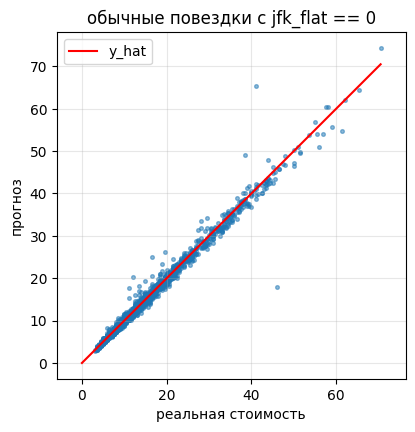

по тарифу: 2.5 1.5527950310559007 0.5
по модели: 2.0526875927982746 1.1242223843346077 0.3667038463624945


In [61]:
reg = trips[trips["jfk_flat"] == 0]
# TODO: подберите модель, сравните коэффициенты с тарифом, нарисуйте график.
# Должна получиться переменная theta_base.
X = reg[["distance_km", "minutes"]]
y = reg["fare_usd"]
theta_base = ols_fit(X,y)
y_pred = ols_predict(X, theta_base)

print('theta_base = ', theta_base)
print('R^2 = ', r2(y, y_pred))

plt.figure(figsize=(4.5, 4.5))
plt.scatter(y, y_pred, s=7, alpha = 0.5)
plt.plot([0, y.max()], [0, y.max()], color = 'red', label = 'y_hat')
plt.axis('equal'); plt.xlabel('реальная стоимость'); plt.ylabel('прогноз');
plt.title('обычные повездки c jfk_flat == 0')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#cравнение с тарифом
rate_for_km = 0.50 / 0.322
print('по тарифу:', 2.50, rate_for_km, 0.50)
print('по модели:', theta_base[0], theta_base[1], theta_base[2])

In [62]:
# Проверка задания 2.1 (не меняйте эту ячейку)
assert np.shape(theta_base) == (3,), "theta_base: посадка, за км, за минуту"
assert 0.9 < theta_base[1] < 2.0 and 0.2 < theta_base[2] < 0.7, f"θ = {theta_base}: проверьте признаки и их порядок"
print("Проверка задания 2.1 пройдена")

Проверка задания 2.1 пройдена


**Вывод.** Смысл коэффициентов: theta_0 - плата за посадку, theta_1 - добавка за каждый км, theta_2 - добавка за каждую минуту в пути. По модели получили коэффициенты меньше, чем стоимость по официальному тарифу, поскольку в MНК идет усреднение по всей выборке, а не максимальная ставка. Модель объясняет 98,6% разброса стоимости поездки.

### Задание 2.2. Почему коэффициенты меньше тарифа

Счётчик в каждый момент берёт деньги либо за расстояние, либо за время. Проверьте это: подберите ту же модель отдельно для быстрых поездок (средняя скорость больше 25 км/ч) и для медленных (меньше 12 км/ч). Какой коэффициент в каждой группе приблизился к тарифу?

In [63]:
speed = reg["distance_km"] / (reg["minutes"] / 60)
# TODO: две модели — для быстрых и для медленных поездок.
fast = reg[speed > 25]
slow = reg[speed < 12]

X_fast = fast[['distance_km','minutes']]
y_fast = fast['fare_usd']
theta_fast = ols_fit(X_fast, y_fast)
theta_fast = np.round(theta_fast,3)
X_slow = slow[['distance_km','minutes']]
y_slow = slow['fare_usd']
theta_slow = np.round(theta_slow,3)

print('по тарифу          2.50  1.553  0.50')
print('быстрые поездки   ', theta_fast[0], theta_fast[1], theta_fast[2])
print('медленные поездки ', theta_slow[0], theta_slow[1], theta_slow[2])


по тарифу          2.50  1.553  0.50
быстрые поездки    2.164 1.175 0.341
медленные поездки  2.173 0.835 0.427


**Вывод.** Для медленных поездок theta_2 близко к значению тарифа 0,5, а theta_1 нет, поскольку там учитываются минуты. Для быстрых поездок наоборот - влияет расстояние, поэтому theta_1 близко к тарифному значению.

---
# Задача 3. Поездки в аэропорт

Поездка между Манхэттеном и аэропортом JFK стоит фиксированную сумму, сколько бы километров и минут она ни заняла. Научим модель этому правилу — двумя новыми видами признаков.

### Задание 3.1. Признак-индикатор

Возьмите все поездки, включая поездки в аэропорт. Нарисуйте стоимость против расстояния, выделив поездки в аэропорт цветом. Добавьте признак-индикатор $s$ = `jfk_flat`:

$$\text{стоимость} \approx \theta_0 + \theta_1 \cdot \text{км} + \theta_2 \cdot \text{мин} + \theta_3 s.$$

Сохраните коэффициенты в `theta_group`. Что означает $\theta_3$? Посмотрите на остатки поездок в аэропорт: от скольких до скольких долларов ошибается модель?

theta_group [3.5217 1.1802 0.2489 1.2479]
остатки поездок в аэропорт, мин -29.531  макс  43.933


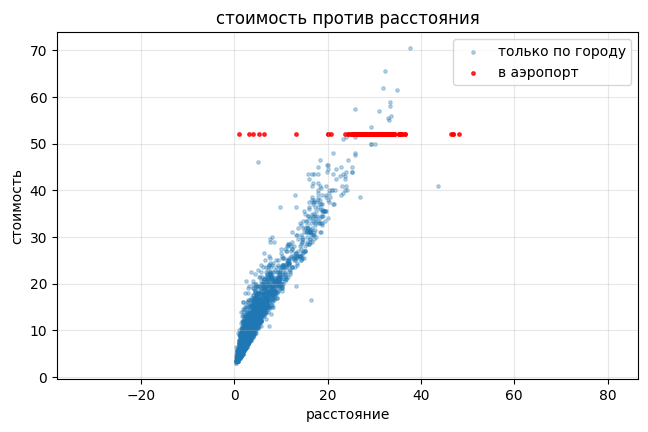

In [64]:
s = trips["jfk_flat"].values
km, mins, fare = trips["distance_km"].values, trips["minutes"].values, trips["fare_usd"].values
# TODO: модель с индикатором, остатки поездок в аэропорт, график.
# Должна получиться переменная theta_group.
X = np.column_stack([km, mins, s])
y = fare
theta_group = ols_fit(X,y)
print('theta_group', theta_group)

y_pred = ols_predict(X, theta_group)
remainder = y - y_pred
remainder_airport = remainder[s == 1]
print('остатки поездок в аэропорт, мин', remainder_airport.min().round(3), ' макс ',remainder_airport.max().round(3))

plt.figure(figsize=(7.5, 4.5))
plt.scatter(km[s == 0], fare[s == 0], s = 6, alpha = 0.3, label = 'только по городу')
plt.scatter(km[s == 1], fare[s == 1], s = 6, alpha = 0.8, label = 'в аэропорт', color = 'red')
plt.axis('equal'); plt.xlabel('расстояние'); plt.ylabel('стоимость');
plt.title('стоимость против расстояния')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [65]:
# Проверка задания 3.1 (не меняйте эту ячейку)
assert np.shape(theta_group) == (4,), "theta_group: свободный член, км, минуты, индикатор аэропорта"
print("Проверка задания 3.1 пройдена")

Проверка задания 3.1 пройдена


**Вывод.** theta_3 отвечает за надбавку за поездку в аэропорт.

### Задание 3.2. Произведения признаков

Индикатор сдвигает прямую, но наклон у всех поездок остаётся общий. Добавьте ещё два признака — произведения $s \cdot \text{км}$ и $s \cdot \text{мин}$:

$$\text{стоимость} \approx \theta_0 + \theta_1 \cdot \text{км} + \theta_2 \cdot \text{мин} + \theta_3 s + \theta_4 \, s \cdot \text{км} + \theta_5 \, s \cdot \text{мин}.$$

Сохраните коэффициенты в `theta_cross`. Чему для поездок в аэропорт равны «цена километра» $\theta_1 + \theta_4$ и «цена минуты» $\theta_2 + \theta_5$? Какую цену поездки в аэропорт находит модель и совпадает ли она с тарифом?

In [72]:
# TODO: добавьте произведения признаков.
# Должна получиться переменная theta_cross.
s = trips["jfk_flat"].values
km, mins, fare = trips["distance_km"].values, trips["minutes"].values, trips["fare_usd"].values

X = np.column_stack([km, mins, s, s*km, s*mins])
y = fare
theta_cross = ols_fit(X,y)
print('theta_cross', theta_cross)
print('цена километра в аэропорт', np.round(theta_cross[1] + theta_cross[4], 3))
print('цена минуты в аэропорт', np.round(theta_cross[2]+ theta_cross[5], 3))

jfk = ols_predict(np.array([[25, 40, 1, 25, 40]]), theta_cross)
print('прогноз jfk', jfk[0].round(3))

theta_cross [ 2.0527  1.1242  0.3667 49.9473 -1.1242 -0.3667]
цена километра в аэропорт -0.0
цена минуты в аэропорт 0.0
прогноз jfk 52.0


In [73]:
# Проверка задания 3.2 (не меняйте эту ячейку)
_flat = 52 if MY_MONTH < "2022-12" else 70
_jfk = ols_predict(np.array([[25, 40, 1, 25, 40]]), theta_cross)[0]
assert abs(_jfk - _flat) < 3, f"поездка в аэропорт по модели стоит ${_jfk:.1f}: проверьте признаки-произведения и их порядок"
print("Проверка задания 3.2 пройдена")

Проверка задания 3.2 пройдена


**Вывод.** Для поездок в аэропорт цена минуты и цена километра равны нулю, поскольку тариф в аэропорт фиксированный, на него не влияют ни минуты, ни километры. Цена поездки в аэропорт по модели - 52 доллара, она совпадает с тарифом.

### Задание 3.3. Прогноз

Спрогнозируйте по модели из задания 3.2 стоимость двух поездок: по городу — `MY_TRIP` вашего варианта (километры и минуты), и в аэропорт JFK — 25 км за 45 минут. Сохраните оба прогноза в `forecast` (сначала по городу, потом в аэропорт).

Сколько стоила бы та же поездка в аэропорт по модели из задания 2.1? Таксопарк хочет оценить по модели выручку от поездок в аэропорт: какая из двух моделей для этого годится и почему?

In [ ]:
city_trip = list(MY_TRIP)
airport_trip = [25, 45]
# TODO: прогноз по модели из задания 3.2 и сравнение с моделью из задания 2.1.
# Должна получиться переменная forecast.

**Вывод.** *(ваш текст)*

---
## Итоги домашней работы

Кратко ответьте на вопросы:

1. Почему модель из задания 2.1 нельзя применять к поездкам в аэропорт, хотя $R^2$ у неё высокий?
2. Чем признак-произведение отличается от признака-индикатора: что каждый из них позволяет модели?
3. В вашем месяце тариф старый или новый? Как это видно по коэффициентам, если не заглядывать в календарь?

---

Проверьте перед сдачей: Kernel → Restart & Run All проходит без ошибок, все ячейки **Вывод** заполнены, графики подписаны.

Имя файла — то, что напечатала ячейка с вариантом: `hw02_Ivanov.ipynb`. Если сдаёте исправленную версию, допишите `_v2`.

In [ ]:
# Сводка для проверки (не меняйте эту ячейку)
import json
_summary = {"STUDENT": STUDENT, "месяц": MY_MONTH, "поездка": list(MY_TRIP)}
for _k in ["theta_base", "theta_group", "theta_cross", "forecast"]:
    _v = globals().get(_k)
    _summary[_k] = None if _v is None else np.round(np.asarray(_v, dtype=float), 4).tolist()
print("СВОДКА", json.dumps(_summary, ensure_ascii=False))